### 13. I föregående kapitel gjordes en *EDA* på datasetet "hr_employee_data.xlsx". Gör nu ett komplett ML-flöde där den beroende variabeln, $y$, är `left`. Om den variabeln är 1 så betyder det att den anställde har lämnat företaget och om den är 0 så betyder det att den anställde inte har lämnat företaget, det vill säga jobbar kvar. 


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

warnings.filterwarnings("ignore")

print("Importer klara!")

Importer klara!


# 1. Ladda data

In [27]:
df = pd.read_excel("../../data/hr_employee_data.xlsx")

print(f"Datamängd storlek: {df.shape}")
print(f"\nKolumner: {df.columns.tolist()}")
print(f"\nMålvariabel fördelning:")
print(df["left"].value_counts())
print(f"\nProcentuell fördelning:")
print(df["left"].value_counts(normalize=True) * 100)

Datamängd storlek: (14999, 11)

Kolumner: ['Emp_Id', 'satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years', 'Department', 'salary']

Målvariabel fördelning:
left
0    11428
1     3571
Name: count, dtype: int64

Procentuell fördelning:
left
0    76.191746
1    23.808254
Name: proportion, dtype: float64


# 2. Förbereda data

In [28]:
# Ta bort saknade värden
df_clean = df.dropna()

print(f"Datamängd efter dropna: {df_clean.shape}")

# Separera X och y
y = df_clean["left"]
X = df_clean.drop("left", axis=1)

# Identifiera kategoriska och numeriska variabler
categorical_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print(f"\nKategoriska variabler: {categorical_cols}")
print(f"Numeriska variabler: {numeric_cols}")

Datamängd efter dropna: (14999, 11)

Kategoriska variabler: ['Emp_Id', 'Department', 'salary']
Numeriska variabler: ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'promotion_last_5years']


# 3. Koda kategoriska variabler

In [29]:
X_encoded = X.drop("Emp_Id", axis=1).copy()

categorical_cols = X_encoded.select_dtypes(
    include=["object", "string"]
).columns.tolist()

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])
    label_encoders[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print(f"\nX efter kodning: {X_encoded.shape}")
print(X_encoded.head())

Department: {'IT': np.int64(0), 'RandD': np.int64(1), 'accounting': np.int64(2), 'hr': np.int64(3), 'management': np.int64(4), 'marketing': np.int64(5), 'product_mng': np.int64(6), 'sales': np.int64(7), 'support': np.int64(8), 'technical': np.int64(9)}
salary: {'high': np.int64(0), 'low': np.int64(1), 'medium': np.int64(2)}

X efter kodning: (14999, 9)
   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  promotion_last_5years  Department  \
0                   3              0                      0           7   
1             

# 4. Dela data i train, val och test

In [30]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full)

print(f"Train storlek: {X_train.shape}")
print(f"Val storlek: {X_val.shape}")
print(f"Test storlek: {X_test.shape}")
print(f"\nTrain fördelning: {y_train.value_counts().to_dict()}")
print(f"Val fördelning: {y_val.value_counts().to_dict()}")
print(f"Test fördelning: {y_test.value_counts().to_dict()}")

Train storlek: (8999, 9)
Val storlek: (3000, 9)
Test storlek: (3000, 9)

Train fördelning: {0: 6856, 1: 2143}
Val fördelning: {0: 2286, 1: 714}
Test fördelning: {0: 2286, 1: 714}


# 5. Träna Logistic Regression

In [31]:
print("=== Logistic Regression ===")

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)

# Prediktioner
y_train_pred_lr = lr_model.predict(X_train)
y_val_pred_lr = lr_model.predict(X_val)
y_test_pred_lr = lr_model.predict(X_test)

# Evaluera
print(f"\nTrain Accuracy: {accuracy_score(y_train, y_train_pred_lr):.4f}")
print(f"Val Accuracy: {accuracy_score(y_val, y_val_pred_lr):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred_lr):.4f}")

print(f"\nVal Precision: {precision_score(y_val, y_val_pred_lr):.4f}")
print(f"Val Recall: {recall_score(y_val, y_val_pred_lr):.4f}")
print(f"Val F1: {f1_score(y_val, y_val_pred_lr):.4f}")

=== Logistic Regression ===

Train Accuracy: 0.7645
Val Accuracy: 0.7673
Test Accuracy: 0.7697

Val Precision: 0.5219
Val Recall: 0.2675
Val F1: 0.3537


# 6. Träna Random Forest

In [32]:
print("=== Random Forest ===")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Prediktioner
y_train_pred_rf = rf_model.predict(X_train)
y_val_pred_rf = rf_model.predict(X_val)
y_test_pred_rf = rf_model.predict(X_test)

# Evaluera
print(f"\nTrain Accuracy: {accuracy_score(y_train, y_train_pred_rf):.4f}")
print(f"Val Accuracy: {accuracy_score(y_val, y_val_pred_rf):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred_rf):.4f}")

print(f"\nVal Precision: {precision_score(y_val, y_val_pred_rf):.4f}")
print(f"Val Recall: {recall_score(y_val, y_val_pred_rf):.4f}")
print(f"Val F1: {f1_score(y_val, y_val_pred_rf):.4f}")

=== Random Forest ===

Train Accuracy: 1.0000
Val Accuracy: 0.9917
Test Accuracy: 0.9893

Val Precision: 0.9971
Val Recall: 0.9678
Val F1: 0.9822


# 7. Jämför modeller

In [33]:
print("=== Jämförelse på testdata ===")
print(f"\nLogistic Regression:")
print(f"  Accuracy: {accuracy_score(y_test, y_test_pred_lr):.4f}")
print(f"  Precision: {precision_score(y_test, y_test_pred_lr):.4f}")
print(f"  Recall: {recall_score(y_test, y_test_pred_lr):.4f}")
print(f"  F1: {f1_score(y_test, y_test_pred_lr):.4f}")

print(f"\nRandom Forest:")
print(f"  Accuracy: {accuracy_score(y_test, y_test_pred_rf):.4f}")
print(f"  Precision: {precision_score(y_test, y_test_pred_rf):.4f}")
print(f"  Recall: {recall_score(y_test, y_test_pred_rf):.4f}")
print(f"  F1: {f1_score(y_test, y_test_pred_rf):.4f}")

print(f"\n=== Confusion matrix - Random Forest ===")
cm = confusion_matrix(y_test, y_test_pred_rf)
print(cm)
print(f"\nClassification Report:")
print(classification_report(y_test, y_test_pred_rf, target_names=["Stannar", "Lämnar"]))

=== Jämförelse på testdata ===

Logistic Regression:
  Accuracy: 0.7697
  Precision: 0.5328
  Recall: 0.2619
  F1: 0.3512

Random Forest:
  Accuracy: 0.9893
  Precision: 0.9942
  Recall: 0.9608
  F1: 0.9772

=== Confusion matrix - Random Forest ===
[[2282    4]
 [  28  686]]

Classification Report:
              precision    recall  f1-score   support

     Stannar       0.99      1.00      0.99      2286
      Lämnar       0.99      0.96      0.98       714

    accuracy                           0.99      3000
   macro avg       0.99      0.98      0.99      3000
weighted avg       0.99      0.99      0.99      3000



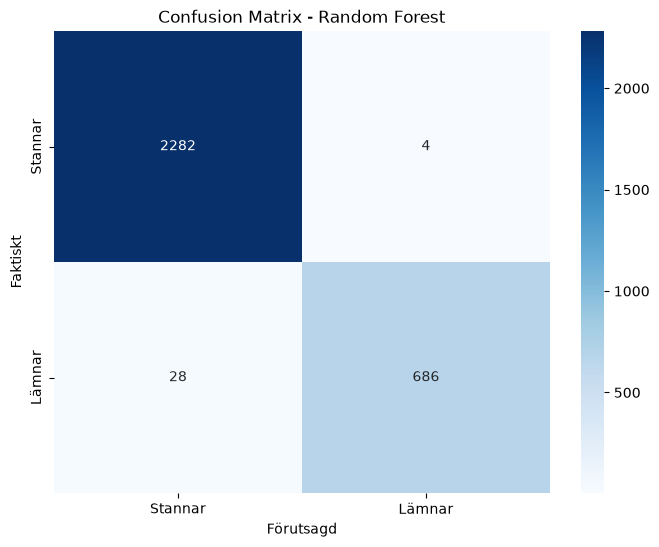

In [34]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stannar", "Lämnar"],
    yticklabels=["Stannar", "Lämnar"],
)
plt.title("Confusion Matrix - Random Forest")
plt.ylabel("Faktiskt")
plt.xlabel("Förutsagd")
plt.show()

# 8. Feature importance från Random Forest

=== Feature importance ===

=== Alla features ===
                 feature  procent
0     satisfaction_level    33.11
4     time_spend_company    18.27
2         number_project    17.80
3   average_montly_hours    15.61
1        last_evaluation    12.35
7             Department     1.35
8                 salary     0.90
5          Work_accident     0.52
6  promotion_last_5years     0.09


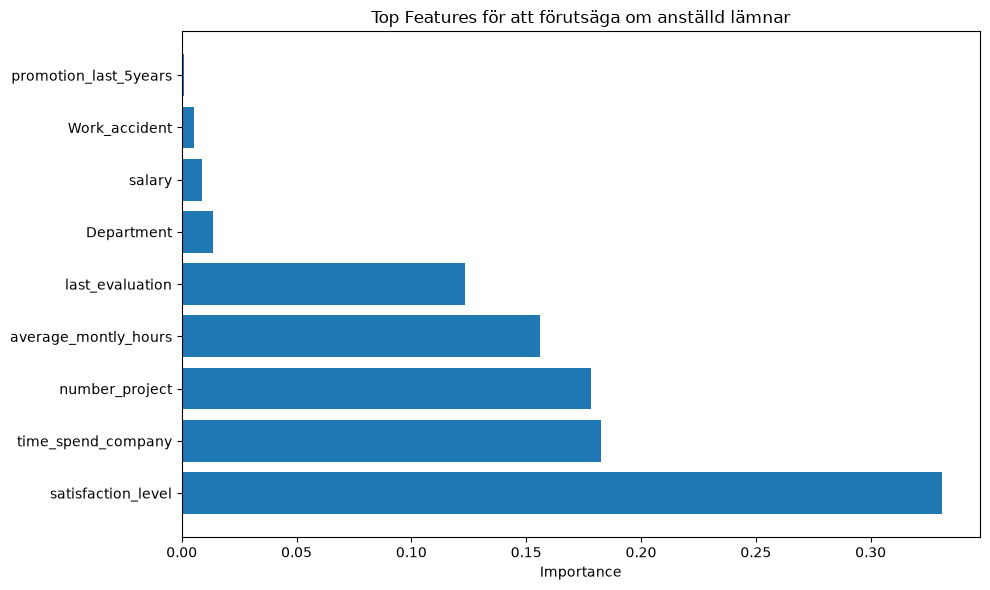

In [36]:
print("=== Feature importance ===")
feature_importance = pd.DataFrame(
    {"feature": X_encoded.columns, "importance": rf_model.feature_importances_}
).sort_values("importance", ascending=False)


print("\n=== Alla features ===")
all_features = feature_importance.copy()
all_features["procent"] = (all_features["importance"] * 100).round(2)
print(all_features[["feature", "procent"]])

plt.figure(figsize=(10, 6))
top_n = min(10, len(feature_importance))
plt.barh(range(top_n), feature_importance["importance"].head(top_n).values)
plt.yticks(range(top_n), feature_importance["feature"].head(top_n).values)
plt.xlabel("Importance")
plt.title("Top Features för att förutsäga om anställd lämnar")
plt.tight_layout()
plt.show()

## Slutsats

Random Forest presterar bättre än Logistic Regression för detta klassificeringsproblem. Modellen kan förutsäga om en anställd lämnar företaget med god noggrannhet genom att titta på faktorer som arbetsmiljö, antal projekt, arbetstimmar och befordringsstatus.